# DCB benchmark: Turon, Dávila, Camanho and Costa (2007)

A. Turon, C. G. Dávila, P. P. Camanho and J. Costa, *An engineering solution for mesh size effects in the simulation of delamination using cohesive zone models*, Eng. Fract. Mech. 2007; 74:1665-1682.

DCB of T300/977-2 (Section 4, Table 3):

- specimen 150 mm long, 20 mm wide, two arms of 1.98 mm, $a_0 = 55$ mm;
- $E_{11} = 150$ GPa, $E_{22} = E_{33} = 11$ GPa, $G_{12} = G_{13} = 6$ GPa, $G_{23} = 3.7$ GPa, $\nu_{12} = \nu_{13} = 0.25$, $\nu_{23} = 0.45$, $G_{Ic} = 0.352$ N/mm, $\tau_3^0 = 60$ MPa;
- 2D plane strain, two layers of 4-node elements with 4-node cohesive elements (ABAQUS UEL), $K = 10^6$ N/mm$^3$;
- Fig. 5: mesh sizes $l_e$ from 0.125 to 4 mm with the nominal strength; Fig. 7: strength reduced to keep 5 elements in the cohesive zone; Fig. 8: peak loads against the element length; Fig. 9: penalty stiffness from 10 to $10^{16}$ N/mm$^3$;
- experimental curve in Figs. 5, 7 and 9.

The free-edge delamination of Section 5 is not a DCB and is not included.

**Conventions.** The displacement of Figs. 5 and 7 is taken as the opening $\delta$ between the loading points.

**Digitised data.** The curves were read from Figs. 5, 8 and 9 by eye, with an estimated uncertainty of $\pm 0.2$ mm and $\pm 2$ N.

In [1]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

sys.path.insert(0, os.path.abspath('.'))
import dcb_utils as du

# True runs panels again, otherwise the results saved in RESULTS are loaded
RERUN = False
RESULTS = 'results'


## FE-based DCB cases

In [2]:
t300 = dict(E1=150000., E2=11000., nu12=0.25, G12=6000., h=1.98, b=20.,
            L=150., a0=55., G1c=0.352)

fe_cases = {
    'le0.125_tau60': dict(t300, tau_o=60., k_o=1.e6,
        label='$l_e$ = 0.125 mm, $\\tau^0$ = 60 MPa',
        source='Figs. 5 and 8',
        model='2D plane strain, 4-node elements, cohesive elements of 0.125 mm, K = 1e6 N/mm3',
        Pmax_fig8=57.,
        curves={
            'cohesive FE, le = 0.125 mm (Fig. 5)': (np.array([0, 2.0, 4.0, 5.0, 5.3, 6.0, 7.0, 8.0, 9.0]),
                                                    np.array([0, 22., 44., 55., 57., 53., 49., 46., 43.])),
        },
        notes='Converged mesh (le <= 0.5 mm). Peak load of Fig. 8, le = 0.125 mm: about 57 N.'),
    'le1_tau26': dict(t300, tau_o=26., k_o=1.e6,
        label='$l_e$ = 1 mm, $\\tau^0$ = 26 MPa (Eq. 12, $N_e$ = 5)',
        source='Figs. 7 and 8',
        model='2D plane strain, cohesive elements of 1 mm with reduced strength',
        curves={},
        notes='Peak load within 1% of the fine mesh according to Fig. 8; curve not digitised.'),
    'K_study': dict(t300, tau_o=60., k_o=None,
        label='penalty stiffness study', source='Fig. 9',
        model='mesh of 2.5 mm, K = 10, 1e3, 1e4, Eq. (7) = 5.55e5 and 1e16 N/mm3',
        curves={},
        notes='The curves for K >= 1e4 N/mm3 are virtually identical (Section 4.2).'),
}


## Experimental DCB tests

In [3]:
exp_tests = {
    'DCB_T300_9772': dict(
        fe_case='le0.125_tau60',
        source='experimental curve of Figs. 5, 7 and 9 (T300/977-2, Table 3 refs. [10, 39])',
        curves={
            'experiment (Fig. 5)': (np.array([0, 2.0, 4.0, 4.8, 5.5, 6.0, 7.0, 8.0, 10.0, 12.0, 14.0, 16.0]),
                                    np.array([0, 26., 52., 62., 60., 57., 52., 49., 45., 40., 37., 35.])),
        },
        notes='Fibre bridging raises the experimental curve after the peak (Section 5.2 of the paper).'),
}


## panels model

The DCB is modelled with `dcb_utils.solve_dcb`: CLPT panels, far end clamped, arm tips opened symmetrically to $\pm\delta/2$ by prescribed displacements, a cohesive domain (`SB_TSL`, bilinear law) ahead of the initial crack front and a perfect bond (`SB`) over the rest of the bonded region. The load is the reaction of the prescribed displacement.

Discretisation, from the convergence study of `doc/source/cohesive_zone.rst` (15 terms and 120 Gauss columns over the 17 mm cohesive domain of the reference DCB):

- terms along $x$ of the cohesive domain: $m = 1.5\,\lambda\,L_{tsl}$, with $\lambda = (k_o/4D_{11})^{1/4}$ the decay rate of the opening ahead of the process zone, at most 25;
- Gauss columns: $n_x = 10\,L_{tsl}/l_{cz}$, with $l_{cz} = 0.88\,E_2 G_{Ic}/\tau_o^2$ (Turon et al. 2007), which keeps about 6 points in the cohesive zone at the middle of the domain;
- the cohesive domain covers the crack growth up to the last opening plus a margin of $2\pi/\lambda + 3 l_{cz}$ for the process zone and the compressive lobe ahead of it; the opening range is limited so that $L_{tsl}$ stays below the length resolved with 25 terms.

The penalty stiffness is $k_o = 10^5$ N/mm$^3$ unless stated otherwise. Turon et al. (2007, Fig. 9) show that the load-displacement curve of the DCB does not change for $k_o \geq 10^4$ N/mm$^3$, and a lower $k_o$ gives a longer decay length $1/\lambda$, which the Ritz basis resolves with fewer terms.


In [4]:
def setup(case, k_o=1.e5, growth_max=None, n_steps=60, margin_factor=1.):
    """Cohesive domain, discretisation and openings of a panels run"""
    c = dict(case)
    c['k_o'] = k_o
    lam, lcz, L_max = du.resolution(c)
    margin = margin_factor*(2*np.pi/lam + 3*lcz)
    L_avail = c['L'] - c['a0']
    growth = min(L_max, L_avail) - margin
    if growth_max is not None:
        growth = min(growth, growth_max)
    L_tsl = min(growth + margin, L_avail)
    c = du.discretize(c, L_tsl)
    # opening when the crack reaches a0 + growth, corrected beam theory
    EI = du.D11(c)*c['b']
    dh = du.chi_williams(c['E1'], c['E2'], c['G12'])*c['h']
    ae = c['a0'] + growth + dh
    delta_max = 2/3*ae**2*np.sqrt(c['G1c']*c['b']/EI)
    openings = np.linspace(delta_max/n_steps, delta_max, n_steps)
    print(f"{case.get('label', '')}: lambda={lam:.3f} 1/mm, lcz={lcz:.2f} mm, "
          f"L_tsl={c['L_tsl']:.1f} mm, m_tsl={c['m_tsl']}, nx={c['nx']}, "
          f"delta_max={delta_max:.2f} mm")
    return c, openings


In [5]:
runs = {}
key = 'le0.125_tau60'
case, openings = setup(fe_cases[key])
runs[key] = (case, du.run_or_load(case, openings, f'{RESULTS}/turon2007_{key}.npz', rerun=RERUN))


$l_e$ = 0.125 mm, $\tau^0$ = 60 MPa: lambda=0.712 1/mm, lcz=0.95 mm, L_tsl=23.4 mm, m_tsl=25, nx=250, delta_max=6.26 mm


### Sensitivity to the penalty stiffness

The paper uses $K = 10^6$ N/mm$^3$. The same case is run with $k_o = 10^6$ N/mm$^3$ over a shorter opening range, since the faster decay of the opening ahead of the process zone needs more terms per unit length.

In [6]:
case_K, openings_K = setup(fe_cases[key], k_o=1.e6)
runs['K1e6'] = (case_K, du.run_or_load(case_K, openings_K, f'{RESULTS}/turon2007_{key}_K1e6.npz',
                                       rerun=RERUN))


$l_e$ = 0.125 mm, $\tau^0$ = 60 MPa: lambda=1.265 1/mm, lcz=0.95 mm, L_tsl=13.2 mm, m_tsl=25, nx=140, delta_max=5.18 mm


## Comparison

| curve | K0 (N/mm) | Pmax (N) | delta at Pmax (mm) | dK0, dPmax, d(delta) vs cohesive FE, le = 0.125 mm (Fig. 5) | dK0, dPmax, d(delta) vs experiment (Fig. 5) |
|---|---|---|---|---|---|
| cohesive FE, le = 0.125 mm (Fig. 5) | 11.00 | 57.0 | 5.30 | - | -15.4%, -8.1%, +10.4% |
| experiment (Fig. 5) | 13.00 | 62.0 | 4.80 | +18.2%, +8.8%, -9.4% | - |
| panels, $k_o$ = 1e5 | 16.27 | 64.1 | 4.18 | +47.9%, +12.4%, -21.2% | +25.2%, +3.3%, -13.0% |
| panels, $k_o$ = 1e6 | 16.41 | 64.0 | 4.23 | +49.2%, +12.4%, -20.2% | +26.2%, +3.3%, -11.9% |
| LEFM, simple beam theory | 17.58 | 67.4 | 3.83 | +59.8%, +18.2%, -27.7% | +35.2%, +8.6%, -20.2% |
| LEFM, corrected beam theory | 14.56 | 63.3 | 4.34 | +32.4%, +11.0%, -18.0% | +12.0%, +2.0%, -9.5% |

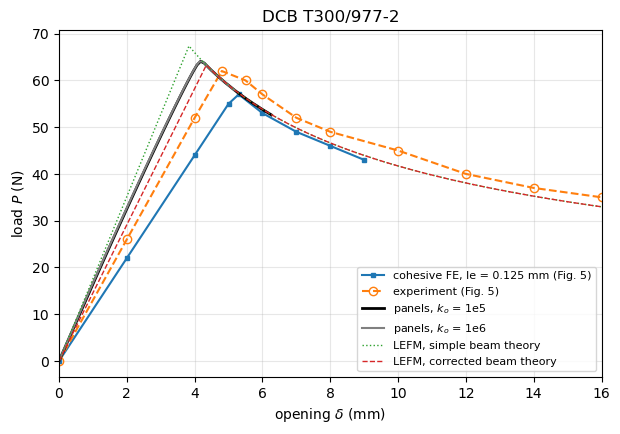

panels le0.125_tau60: m_tsl=25, nx=250, 60 openings, 0 bisections, crack growth 13.0 mm
panels K1e6: m_tsl=25, nx=140, 60 openings, 0 bisections, crack growth 6.5 mm


In [7]:
fe = fe_cases[key]
ex = exp_tests['DCB_T300_9772']
case, res = runs[key]
_, resK = runs['K1e6']
rows = dict(fe['curves'])
rows.update(ex['curves'])
rows['panels, $k_o$ = 1e5'] = (np.concatenate(([0.], res['delta'])), np.concatenate(([0.], res['P'])))
rows['panels, $k_o$ = 1e6'] = (np.concatenate(([0.], resK['delta'])), np.concatenate(([0.], resK['P'])))
rows['LEFM, simple beam theory'] = du.lefm_curve(fe, fe['a0'] + 60)
rows['LEFM, corrected beam theory'] = du.lefm_curve(fe, fe['a0'] + 60, corrected=True)
display(Markdown(du.markdown_table(rows, ref=['cohesive FE, le = 0.125 mm (Fig. 5)', 'experiment (Fig. 5)'])))
fig, ax = plt.subplots(figsize=(7, 4.5))
style = {'experiment (Fig. 5)': dict(ls='--', marker='o', mfc='none'),
         'cohesive FE, le = 0.125 mm (Fig. 5)': dict(marker='s', ms=3),
         'panels, $k_o$ = 1e5': dict(lw=2, color='k'),
         'panels, $k_o$ = 1e6': dict(lw=1.5, color='0.5'),
         'LEFM, simple beam theory': dict(ls=':', lw=1),
         'LEFM, corrected beam theory': dict(ls='--', lw=1)}
du.plot_curves(ax, rows, style)
ax.set_xlim(0, 16)
ax.set_title('DCB T300/977-2')
plt.show()
for k, (c, r) in runs.items():
    print(f"panels {k}: m_tsl={c['m_tsl']}, nx={c['nx']}, {len(r['delta'])} openings, "
          f"{r['failed']} bisections, crack growth {r['a'][-1] - fe['a0']:.1f} mm")


**Remarks.**

- The FE model is 2D plane strain; panels uses CLPT plates of 20 mm width with free edges, without transverse shear deformation.
- The experimental curve is above the models after the peak because of fibre bridging, which the bilinear law does not represent.
- The digitised curves are approximate, $\pm 2$ N.

## Discussion

- **Peak load.** panels predicts 64.1 N at an opening of 4.18 mm with $k_o = 10^5$ N/mm$^3$ and 64.0 N at 4.23 mm with the $k_o = 10^6$ N/mm$^3$ of the paper: the penalty stiffness changes the peak by 0.03%, as found by Turon et al. for their FE model (Fig. 9). The peak is 3.3% above the experimental peak (about 62 N) and 1.3% above the corrected beam theory (63.3 N). It is 12% above the cohesive FE result with the finest mesh (about 57 N, Figs. 5 and 8), which is itself 10% below the corrected beam theory.
- **Initial stiffness.** panels (16.3 N/mm) lies between the simple (17.6 N/mm) and the corrected (14.6 N/mm) beam theories, as expected from CLPT arms on an elastic foundation without transverse shear. The FE (about 11 N/mm) and experimental (about 13 N/mm) curves of Fig. 5 are 12-25% more compliant than the corrected beam theory. That difference is larger than the effect of shear and root rotation, which suggests that the displacement plotted in the paper includes compliance that no beam model has, e.g. of the loading hinges, or a different definition of the displacement. This is a hypothesis; the paper does not give enough detail to confirm it, so the openings at the peak are not compared.
- **After the peak.** The crack grew 13 mm in the panels run with $k_o = 10^5$ N/mm$^3$ and 6.5 mm with $10^6$ N/mm$^3$ (shorter cohesive domain, see above). The experimental curve decreases more slowly than the models because of fibre bridging.
- **Robustness.** Both runs converged at every opening without bisection.